In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
from few.trajectory.ode.flux import KerrEccEqFlux
import matplotlib.pyplot as plt
import numpy as np

# Dephasing on a fixed total duration

In [3]:
traj_1PA = EMRIInspiral(func=Trajectory1PAT1R)
traj_0PA = EMRIInspiral(func=KerrEccEqFlux)

In [43]:
m1 = 1e6       # primary mass [solar masses]

a  = 1e-9       # primary spin chi1 (dimensionless)
chi2  = 0.3   # secondary spin
p0 = 30.0      # initial orbital separation [M]

dt = 5.   # time step [s]
T  = 4    # total duration [yr]


logm2Tab = np.linspace(-2, 3, 2000)
m2Tab = 10**logm2Tab
nuTab = m1*m2Tab/(m1 + m2Tab)**2.

In [44]:
dephasing = []
for m2 in m2Tab:
    t1PA, p1PA, e1PA, x1PA, Phi_phi1PA, Phi_theta1PA, Phi_r1PA, deltaM1PA, deltachit1PA = traj_1PA(
        m1, m2,
        a,        # chi1 (primary spin)
        p0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        chi2,
        T=T,
        dt=dt,
        in_coordinate_time=False
    )

    t0PA, p0PA, e0PA, x0PA, Phi_phi0PA, Phi_theta0PA, Phi_r0PA = traj_0PA(
        m1, m2,
        a,        # chi1 (primary spin)
        p0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        T=T,
        dt=dt,
        in_coordinate_time=False
    )

    dephasing.append(np.abs(Phi_phi1PA[-1] - Phi_phi0PA[-1]))


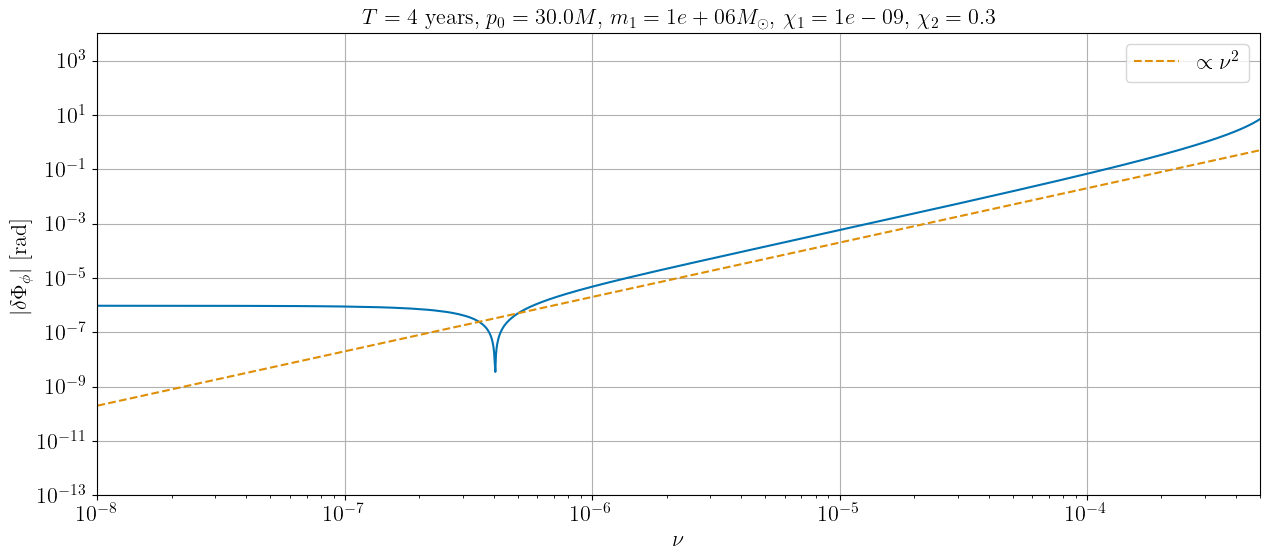

In [62]:
fontsize = 16
import seaborn as sns
colorblind_palette = sns.color_palette('colorblind')
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

colorblind_hex = [mcolors.to_hex(color) for color in colorblind_palette]

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

plt.figure(figsize=(15, 6))

plt.plot(nuTab, dephasing, color=colorblind_hex[0])
plt.plot(nuTab,2e6 * nuTab**(2.), linestyle='--', label=r"$\propto \nu^2$", color=colorblind_hex[1])

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\nu$",fontsize=fontsize)
plt.ylabel(r"$|\delta \Phi_{\phi}|$ [rad]",fontsize=fontsize)
plt.ylim(1e-13,1e4)
plt.xlim(1e-8,5e-4)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.title(r"$T={}$ years, $p_0={} M$, $m_1={:.0e}M_\odot$, $\chi_1={}$, $\chi_2={}$".format(T, p0, m1, a, chi2),fontsize=fontsize)
plt.grid()
plt.legend(fontsize=fontsize)

plt.show()

# Dephasing fixed total duration

In [13]:
traj_1PA = EMRIInspiral(func=Trajectory1PAT1R)
traj_0PA = EMRIInspiral(func=KerrEccEqFlux)

In [34]:
m1 = 1e6       # primary mass [solar masses]
m2 = 1e0       # secondary mass [solar masses]
nu = m1*m2/(m1 + m2)**2.

a  = 0.0       # primary spin chi1 (dimensionless)
chi2  = 0.0   # secondary spin
p0 = 8.0      # initial orbital separation [M]

dt = 1.   # time step [s]
TTab  = np.linspace(1e-3, 4, 100)    # total duration [yr]

In [35]:
dephasing = []
for T in TTab:
    t1PA, p1PA, e1PA, x1PA, Phi_phi1PA, Phi_theta1PA, Phi_r1PA, deltaM1PA, deltachit1PA = traj_1PA(
        m1, m2,
        a,        # chi1 (primary spin)
        p0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        chi2,
        T=T,
        dt=dt,
        in_coordinate_time=False
    )

    t0PA, p0PA, e0PA, x0PA, Phi_phi0PA, Phi_theta0PA, Phi_r0PA = traj_0PA(
        m1, m2,
        a,        # chi1 (primary spin)
        p0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        T=T,
        dt=dt,
        in_coordinate_time=False
    )

    dephasing.append(np.abs(Phi_phi1PA[-1] - Phi_phi0PA[-1]))


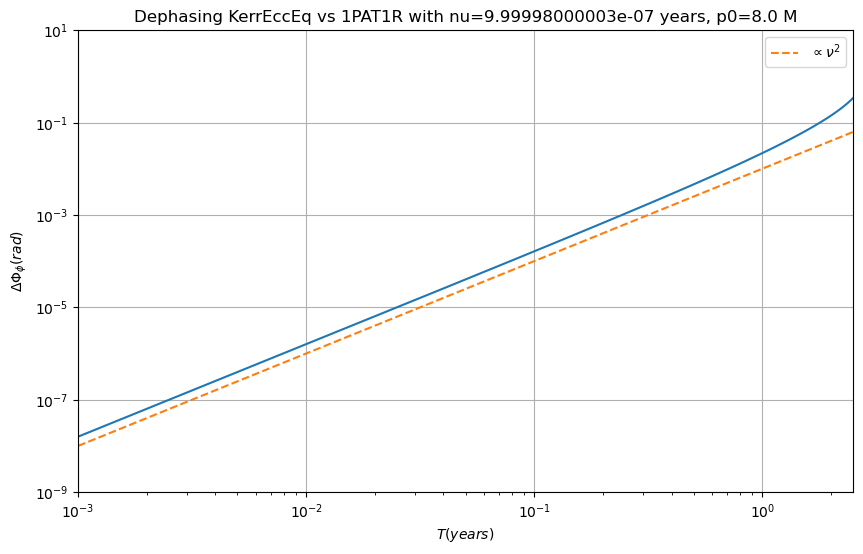

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(TTab, dephasing)
plt.plot(TTab,1e-2 * TTab**(2.), linestyle='--', label=r"$\propto \nu^2$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$T (years)$")
plt.ylabel(r"$\Delta \Phi_{\phi} (rad)$")
plt.ylim(1e-9,1e1)
plt.xlim(1e-3,2.5)
plt.title("Dephasing KerrEccEq vs 1PAT1R with nu={} years, p0={} M".format(nu, p0))
plt.grid()
plt.legend()
plt.show()